# 03 - The out-of-memory detector

`headroom/06` found the only place in this project where node telemetry clearly carries
a failure mechanism. Measured against **each job's own starting level**, node active
memory separates `OUT_OF_MEMORY` jobs from matched `COMPLETED` ones at
**AUC 0.871, 95 % CI [0.802, 0.923]**, and the separation is flat from five minutes
before death out to two hours - these jobs do not deteriorate, they start high and stay
high.

It also found why that could not be turned into anything: **130 OOM jobs exist on the
GPU nodes, 57 of them long enough to produce a single window.** `headroom/07` showed the
pipeline could represent the signal (AUC 0.890 after windowing) and still could not
learn it.

`01` changed the denominator. The cluster holds **4,499 OOM jobs, 1,303 of them
scorable** - 22.9x more. This notebook asks the two questions that were unanswerable at
n = 57:

1. **Does the mechanism replicate?** The GPU result rests on 58 jobs. Replication on a
   different hardware population, with an interval a third of the width, is what turns
   it from a suggestive finding into a fact.
2. **Can a model learn it now?** Not "predict any failure" - a dedicated
   `OUT_OF_MEMORY` detector, which is the narrow, specific condition worth being good at.

## Pre-registration

**O1 - replication.** Baseline-relative `mem_active` will separate OOM from matched
`COMPLETED` jobs at **AUC >= 0.75** on the non-GPU population, with a 95 % interval
**narrower than 0.10** (the GPU interval spanned 0.121).

**O2 - learnability.** For an OOM-specific target, **telemetry will beat job context**
in job-level AP. This is the claim `headroom/` had to retract at n = 57, and it is the
one that decides whether the technique this project built has any subject at all.

**O3 - baseline-relative features.** Adding per-job delta columns will improve OOM
job-level AP. At GPU scale they cost 35 % of OOM lift; the stated reason was sample
size, so at 22.9x the sample the sign should flip.

**O4 - shape.** Separation will stay flat across lead-time bands out to two hours,
replicating the "elevated from the start, not deteriorating" shape rather than the
gradual-degradation picture the project originally assumed.

Any of these can land the other way. O2 is the one that matters: if telemetry still
loses to paperwork with 22.9x the positives, the conclusion is that this telemetry does
not contain the mechanism, and that is a finding rather than a failure.

In [1]:
# --- Setup ------------------------------------------------------------------
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW  = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

WINDOW, SNAP_S = 40, 30.0
FLOOR_S  = (WINDOW // 2 - 1) * SNAP_S     # 570 s
DEC      = 4
VAL_FRAC = 0.20
HORIZONS = [0.5, 2.0]
MIN_RUNTIME_S = 600                        # a job needs 10 min of telemetry to be usable
N_CONTROL     = 3_000                      # matched COMPLETED controls for the raw pass
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts_01 = json.load(open(DATA / "facts_01.json"))
FEATURES = facts_01["features"]
facts = {}
print(f"{facts_01['scorable_oom_jobs']:,} scorable OOM jobs "
      f"({facts_01['scorable_oom_jobs_gpu']} of them on GPU nodes)")

1,303 scorable OOM jobs (57 of them on GPU nodes)


## Step 1 - Replication on raw snapshots

Same recipe as `headroom/06`, on a population that shares none of its jobs. Controls are
`COMPLETED` jobs from the **same queues** and the **same runtime band**, so a difference
cannot be explained by "OOM jobs run longer" or "OOM jobs sit on busier queues". The
baseline is the median of each series' **first 10 snapshots**, and every feature is the
change from it.

In [2]:
jobs = pd.read_parquet(DATA / "jobs_all.parquet")
jobs["runtime_s"] = (jobs.last_ts - jobs.first_ts).dt.total_seconds()
oom = jobs[(jobs.state == "OUT_OF_MEMORY") & (jobs.runtime_s >= MIN_RUNTIME_S)]
lo, hi = oom.runtime_s.min(), oom.runtime_s.max()
comp = jobs[(jobs.state == "COMPLETED") & jobs.runtime_s.between(lo, hi)
            & jobs.nodetypes.isin(oom.nodetypes.unique())]
comp = comp.sample(min(len(comp), N_CONTROL), random_state=0)
sel = pd.concat([oom, comp])
print(f"OOM jobs {int((jobs.state=='OUT_OF_MEMORY').sum()):,} total, "
      f"{len(oom):,} with >= {MIN_RUNTIME_S/60:.0f} min of telemetry "
      f"({int((oom.gpu_node==1).sum())} on GPU nodes)")
print(f"matched COMPLETED controls {len(comp):,} | runtime band "
      f"{lo/60:.1f} - {hi/60:.1f} min")

OOM jobs 4,629 total, 1,922 with >= 10 min of telemetry (67 on GPU nodes)
matched COMPLETED controls 3,000 | runtime band 10.0 - 5680.0 min


In [3]:
t0 = time.time()
METRICS = {"node_memory_Active_bytes":   ("node active memory", 1e9, "GB"),
           "node_memory_MemFree_bytes":  ("node free memory",   1e9, "GB"),
           "node_memory_Dirty_bytes":    ("dirty pages",        1e6, "MB"),
           "node_load1":                 ("load average",       1.0, "")}
ids = pd.array(sel.slurm_id.to_numpy())
d = ds.dataset(RAW, format="parquet")
tb = d.to_table(columns=["slurm_id", "node", "timestamp", "state", "end_date"]
                        + list(METRICS),
                filter=ds.field("slurm_id").isin(ids))
S = tb.to_pandas(); del tb; gc.collect()
S = S.sort_values(["slurm_id", "node", "timestamp"], ignore_index=True)
S["ttf_s"] = (S.end_date - S.timestamp).dt.total_seconds()
print(f"{len(S):,} raw snapshots for {S.slurm_id.nunique():,} jobs "
      f"in {time.time()-t0:.0f}s")

2,242,393 raw snapshots for 4,922 jobs in 21s


In [4]:
# --- baseline-relative features --------------------------------------------
# The baseline is computed once and merged back; pandas re-indexes on merge, so the
# deltas must be taken after the merge and not from a mask captured beforehand.
BASE_N = 10
first = S.groupby(["slurm_id", "node"], observed=True).head(BASE_N)
base = first.groupby(["slurm_id", "node"], observed=True)[list(METRICS)].median()
base.columns = [c + "__base" for c in base.columns]
S = S.merge(base, on=["slurm_id", "node"], how="left")
for col in METRICS:
    S[col + "__delta"] = S[col] - S[col + "__base"]
have = S[[c + "__delta" for c in METRICS]].notna().all(axis=1)
S = S[have]
print(f"{S.slurm_id.nunique():,} jobs keep a usable baseline "
      f"({S.groupby('state').slurm_id.nunique().to_dict()})")

4,922 jobs keep a usable baseline ({'COMPLETED': 3000, 'OUT_OF_MEMORY': 1922})


In [5]:
def auc_ci(pos, neg, gp, gn, n_boot=200, seed=0):
    """Rank-sum AUC with a bootstrap over JOBS - snapshots inside a job are not independent."""
    def auc(a, b):
        r = rankdata(np.concatenate([a, b]))
        return (r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))
    point = auc(pos, neg)
    rng = np.random.default_rng(seed)
    up, un = np.unique(gp), np.unique(gn)
    ip = {g: np.flatnonzero(gp == g) for g in up}
    iN = {g: np.flatnonzero(gn == g) for g in un}
    out = []
    for _ in range(n_boot):
        a = np.concatenate([ip[g] for g in rng.choice(up, len(up))])
        b = np.concatenate([iN[g] for g in rng.choice(un, len(un))])
        out.append(auc(pos[a], neg[b]))
    return point, *np.percentile(out, [2.5, 97.5])

last = S[S.ttf_s <= 300]                       # the final five minutes of each series
P = last[last.state == "OUT_OF_MEMORY"]; N = last[last.state == "COMPLETED"]
rows = []
for col, (title, _, _) in METRICS.items():
    for kind, key in [("absolute", col), ("baseline-relative", col + "__delta")]:
        a, lo_, hi_ = auc_ci(P[key].to_numpy(), N[key].to_numpy(),
                             P.slurm_id.to_numpy(), N.slurm_id.to_numpy())
        rows.append(dict(metric=title, kind=kind, auc=a, lo=lo_, hi=hi_,
                         sep=abs(a - .5), width=hi_ - lo_))
A = pd.DataFrame(rows).sort_values("sep", ascending=False)
A.to_csv(DATA / "oom_auc.csv", index=False)
print(f"OOM jobs {P.slurm_id.nunique():,}  vs  COMPLETED controls {N.slurm_id.nunique():,}")
print(A.round(4).to_string(index=False))

OOM jobs 1,863  vs  COMPLETED controls 2,975
            metric              kind    auc     lo     hi    sep  width
node active memory          absolute 0.8566 0.8463 0.8657 0.3566 0.0194
  node free memory          absolute 0.1795 0.1679 0.1932 0.3205 0.0253
      load average          absolute 0.6440 0.6252 0.6609 0.1440 0.0357
       dirty pages          absolute 0.6228 0.6073 0.6392 0.1228 0.0318
node active memory baseline-relative 0.6115 0.5918 0.6296 0.1115 0.0378
  node free memory baseline-relative 0.3983 0.3797 0.4162 0.1017 0.0366
      load average baseline-relative 0.4795 0.4647 0.4959 0.0205 0.0312
       dirty pages baseline-relative 0.4990 0.4864 0.5118 0.0010 0.0253


In [6]:
ma = A[(A.metric == "node active memory") & (A.kind == "baseline-relative")].iloc[0]
o1 = ma.auc >= 0.75 and ma.width < 0.10
print(f"O1  replication of the memory signal : {'CONFIRMED' if o1 else 'REJECTED'}")
print(f"    AUC {ma.auc:.4f}  95 % CI [{ma.lo:.4f}, {ma.hi:.4f}]  width {ma.width:.4f}")
print(f"    GPU-only reference was AUC 0.871 [0.802, 0.923], width 0.121, on 58 jobs")
facts.update(O1=bool(o1), oom_auc=float(ma.auc), oom_auc_lo=float(ma.lo),
             oom_auc_hi=float(ma.hi), oom_jobs_raw=int(P.slurm_id.nunique()))
del S, last, P, N, first, base; gc.collect()

O1  replication of the memory signal : REJECTED
    AUC 0.6115  95 % CI [0.5918, 0.6296]  width 0.0378
    GPU-only reference was AUC 0.871 [0.802, 0.923], width 0.121, on 58 jobs


0

## Step 2 - An OUT_OF_MEMORY detector

Everything up to here in the project trained one model against "any failure state", a
target that `eda/` showed is 70 % walltime exhaustion. This trains against a **single
mechanism**: a window is positive when its own job ends `OUT_OF_MEMORY` within the
horizon, and a job is positive when it ends `OUT_OF_MEMORY`. Nothing else counts.

The target is rare - roughly 1.4 % of scorable jobs - so **lift is not reported as a
selection criterion anywhere below**. `headroom/04` established what that costs.
Selection is on validation job-level AP; the operating point is precision at a fixed
number of alerts.

In [7]:
t0 = time.time()
META = ["slurm_id", "node", "state", "gpu_node", "split", "ttf_end", "w_idx",
        "t_end", "nodetypes", "numnodes"]
pf = pq.ParquetFile(DATA / "windows_all.parquet")
chunks = []
for batch in pf.iter_batches(batch_size=400_000, columns=META + FEATURES):
    d_ = batch.to_pandas()
    chunks.append(d_[d_.w_idx % DEC == 0])
w = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()
w = w.merge(jobs[["slurm_id", "start_date", "numcores"]], on="slurm_id", how="left")
print(f"{len(w):,} windows | {w.slurm_id.nunique():,} jobs | [{time.time()-t0:.0f}s]")

MEAN_COLS = [c for c in FEATURES if c.endswith("__mean")]
w = w.sort_values(["slurm_id", "node", "w_idx"], ignore_index=True)
bw = (w.groupby(["slurm_id", "node"], observed=True)[MEAN_COLS]
        .first().add_suffix("__b"))
w = w.merge(bw, on=["slurm_id", "node"], how="left")
DELTA = []
for c in MEAN_COLS:
    dcol = c.replace("__mean", "__delta")
    w[dcol] = w[c] - w[c + "__b"]
    DELTA.append(dcol)
w = w.drop(columns=[c + "__b" for c in MEAN_COLS])
print(f"{len(DELTA)} baseline-relative columns added")

2,052,964 windows | 92,054 jobs | [14s]


9 baseline-relative columns added


In [8]:
el = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = el / 3600.0
w["sec_into_hour"]       = el % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (el % 3600.0)
w["elapsed_hours_floor"] = np.floor(el / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
C7 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"]
SETS = {"T36 telemetry": FEATURES, "C7  context": C7,
        "T36+C7": FEATURES + C7, "T36+D  telemetry + deltas": FEATURES + DELTA,
        "T36+C7+D everything": FEATURES + C7 + DELTA}

tr_jobs = (w.loc[w.split == "train", ["slurm_id", "t_end"]]
             .groupby("slurm_id").t_end.max().sort_values())
val_ids = set(tr_jobs.index[int(len(tr_jobs) * (1 - VAL_FRAC)):])
w["fold"] = np.where(w.split == "test", "test",
             np.where(w.slurm_id.isin(val_ids), "val", "fit"))
M = {f: (w.fold == f).to_numpy() for f in ["fit", "val", "test"]}

is_oom = (w.state == "OUT_OF_MEMORY").to_numpy()
ttf = w.ttf_end.to_numpy()
def oom_label(H):
    return (is_oom & (ttf >= 0) & (ttf <= H * 3600 - FLOOR_S)).astype(np.int8)

for f in ["fit", "val", "test"]:
    d_ = w[M[f]]
    print(f"{f:5s} windows {int(M[f].sum()):8,}  jobs {d_.slurm_id.nunique():7,}  "
          f"OOM jobs {d_.loc[d_.state=='OUT_OF_MEMORY','slurm_id'].nunique():5,}")

fit   windows 1,297,062  jobs  60,380  OOM jobs   906
val   windows  492,025  jobs  15,096  OOM jobs   120


test  windows  263,877  jobs  16,578  OOM jobs   277


In [9]:
def job_scores(mask, score):
    sub = w.loc[mask, ["slurm_id", "state"]]
    d_ = pd.DataFrame({"slurm_id": sub.slurm_id.to_numpy(),
                       "state": sub.state.astype(str).to_numpy(), "score": score})
    g = d_.groupby("slurm_id").agg(score=("score", "max"), state=("state", "first"))
    return (g.state == "OUT_OF_MEMORY").astype(int).to_numpy(), g.score.to_numpy(), g

def run(fit_mask, cols, eval_mask, y):
    m = lgb.LGBMClassifier(**PARAMS).fit(w.loc[fit_mask, cols], y[fit_mask])
    sc = m.predict_proba(w.loc[eval_mask, cols])[:, 1]
    yj, sj, g = job_scores(eval_mask, sc)
    return m, sc, average_precision_score(yj, sj), float(yj.mean()), yj, sj, g

rows = []
for H in HORIZONS:
    yH = oom_label(H)
    for name, cols in SETS.items():
        _, sc, jap, base, yj, _, _ = run(M["fit"], cols, M["val"], yH)
        wap = average_precision_score(yH[M["val"]], sc)
        rows.append(dict(horizon_h=H, features=name, val_pos_windows=int(yH[M["val"]].sum()),
                         val_oom_jobs=int(yj.sum()), val_job_ap=jap,
                         val_job_base=base, val_win_ap=wap))
    print(f"  H={H} h done  [{time.time()-t0:.0f}s]")
V = pd.DataFrame(rows)
V.to_csv(DATA / "oom_selection.csv", index=False)
print()
print("VALIDATION job-level AP for the OOM target (the selection criterion)")
print(V.pivot(index="horizon_h", columns="features", values="val_job_ap").round(4).to_string())

  H=0.5 h done  [112s]


  H=2.0 h done  [213s]

VALIDATION job-level AP for the OOM target (the selection criterion)
features   C7  context  T36 telemetry  T36+C7  T36+C7+D everything  T36+D  telemetry + deltas
horizon_h                                                                                    
0.5             0.0168         0.0321  0.0356               0.0312                     0.0424
2.0             0.0299         0.0421  0.0377               0.0334                     0.0468


In [10]:
best = V.loc[V.val_job_ap.idxmax()]
BEST_H, BEST_SET = float(best.horizon_h), str(best.features)
print(f"SELECTED -> horizon {BEST_H} h, features {BEST_SET}, "
      f"validation job AP {best.val_job_ap:.4f}")

t_ap = V[V.features == "T36 telemetry"].val_job_ap.max()
c_ap = V[V.features == "C7  context"].val_job_ap.max()
o2 = t_ap > c_ap
print()
print(f"O2  telemetry beats context on OOM   : {'CONFIRMED' if o2 else 'REJECTED'}")
print(f"    telemetry {t_ap:.4f}  vs  context {c_ap:.4f}   "
      f"(ratio {t_ap/c_ap:.2f}x)")

d_ap = V[V.features == "T36+D  telemetry + deltas"].val_job_ap.max()
o3 = d_ap > t_ap
print(f"O3  baseline-relative columns help   : {'CONFIRMED' if o3 else 'REJECTED'}")
print(f"    T36 {t_ap:.4f} -> T36+D {d_ap:.4f}  ({(d_ap/t_ap-1)*100:+.1f} %)")
facts.update(O2=bool(o2), O3=bool(o3), val_ap_telemetry=float(t_ap),
             val_ap_context=float(c_ap), val_ap_delta=float(d_ap),
             selected_horizon_h=BEST_H, selected_features=BEST_SET)

SELECTED -> horizon 2.0 h, features T36+D  telemetry + deltas, validation job AP 0.0468

O2  telemetry beats context on OOM   : CONFIRMED
    telemetry 0.0421  vs  context 0.0299   (ratio 1.41x)
O3  baseline-relative columns help   : CONFIRMED
    T36 0.0421 -> T36+D 0.0468  (+11.1 %)


## Step 3 - One refit, one evaluation on test

In [11]:
yB = oom_label(BEST_H)
trm = M["fit"] | M["val"]
_, sc_t, jap_t, base_t, yj_t, sj_t, gj = run(trm, SETS[BEST_SET], M["test"], yB)

def ap_ci(y, s, n_boot=300, seed=1):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if y[i].sum():
            out.append(average_precision_score(y[i], s[i]))
    return np.percentile(out, [2.5, 97.5])

lo_, hi_ = ap_ci(yj_t, sj_t)
print(f"TEST job-level AP  {jap_t:.4f}   95 % CI [{lo_:.4f}, {hi_:.4f}]")
print(f"  base rate {base_t:.4%}  ->  {jap_t/base_t:.1f}x")
print(f"  {int(yj_t.sum()):,} OOM jobs among {len(yj_t):,} scorable test jobs")
print(f"  validation {best.val_job_ap:.4f} -> test {jap_t:.4f}  "
      f"(shrinkage {best.val_job_ap/jap_t:.2f}x)")
facts.update(test_job_ap=float(jap_t), test_job_ap_lo=float(lo_),
             test_job_ap_hi=float(hi_), test_base=float(base_t),
             test_oom_jobs=int(yj_t.sum()), test_jobs=int(len(yj_t)))

TEST job-level AP  0.0560   95 % CI [0.0475, 0.0669]
  base rate 1.6709%  ->  3.3x
  277 OOM jobs among 16,578 scorable test jobs
  validation 0.0468 -> test 0.0560  (shrinkage 0.84x)


In [12]:
order = np.argsort(-sj_t)
rows = []
for k in [10, 25, 50, 100, 200, 400, 800]:
    if k > len(order):
        continue
    hit = int(yj_t[order[:k]].sum())
    rows.append(dict(flagged=k, precision=hit / k, recall=hit / yj_t.sum(), true_alerts=hit))
OP = pd.DataFrame(rows)
print("Operating points on the test fold (jobs ranked by their highest window score)")
print(OP.round(4).to_string(index=False))
facts["operating_points"] = OP.to_dict("records")

Operating points on the test fold (jobs ranked by their highest window score)
 flagged  precision  recall  true_alerts
      10     0.0000  0.0000            0
      25     0.0000  0.0000            0
      50     0.0200  0.0036            1
     100     0.0300  0.0108            3
     200     0.0250  0.0181            5
     400     0.0350  0.0505           14
     800     0.0912  0.2635           73


## Step 4 - Is the signal still flat over lead time?

`headroom/06` found the separation between OOM and healthy jobs to be the same size two
hours before death as five minutes before it. That shape matters more than its size: a
flat profile means these jobs are **already** in an elevated-memory state rather than
sliding into one, so a warning does not have to be issued at the last moment.

In [13]:
mem_d = "mem_active__delta"
comp_mask = (w.state == "COMPLETED").to_numpy()
edges = [(0, 300), (300, 900), (900, 1800), (1800, 3600), (3600, 7200)]
rows = []
neg = w.loc[comp_mask, mem_d].to_numpy()
neg_g = w.loc[comp_mask, "slurm_id"].to_numpy()
rng = np.random.default_rng(0)
keep = rng.choice(len(neg), size=min(len(neg), 200_000), replace=False)
neg, neg_g = neg[keep], neg_g[keep]
for a, b in edges:
    m_ = is_oom & (ttf >= a) & (ttf < b)
    if m_.sum() < 30:
        continue
    pos = w.loc[m_, mem_d].to_numpy(); pos_g = w.loc[m_, "slurm_id"].to_numpy()
    auc, lo2, hi2 = auc_ci(pos, neg, pos_g, neg_g, n_boot=120)
    rows.append(dict(band=f"{a//60}-{b//60} min", lead_min=a / 60, auc=auc, lo=lo2, hi=hi2,
                     sep=abs(auc - .5), oom_windows=int(m_.sum()),
                     oom_jobs=int(w.loc[m_, "slurm_id"].nunique())))
L = pd.DataFrame(rows)
L.to_csv(DATA / "oom_leadtime.csv", index=False)
print(L.round(4).to_string(index=False))
spread = float(L.sep.max() - L.sep.min())
o4 = spread < 0.10
print()
print(f"O4  separation flat across lead time : {'CONFIRMED' if o4 else 'REJECTED'}")
print(f"    |AUC - 0.5| ranges {L.sep.min():.3f} to {L.sep.max():.3f} (spread {spread:.3f})")
facts.update(O4=bool(o4), leadtime_spread=float(spread))

      band  lead_min    auc     lo     hi    sep  oom_windows  oom_jobs
   0-5 min       0.0 0.3611 0.3292 0.3893 0.1389          364       364
  5-15 min       5.0 0.3391 0.3079 0.3705 0.1609          570       565
 15-30 min      15.0 0.3926 0.3592 0.4253 0.1074          689       670
 30-60 min      30.0 0.3847 0.3548 0.4197 0.1153         1117       865
60-120 min      60.0 0.4557 0.4144 0.4963 0.0443         1383       506

O4  separation flat across lead time : REJECTED
    |AUC - 0.5| ranges 0.044 to 0.161 (spread 0.117)


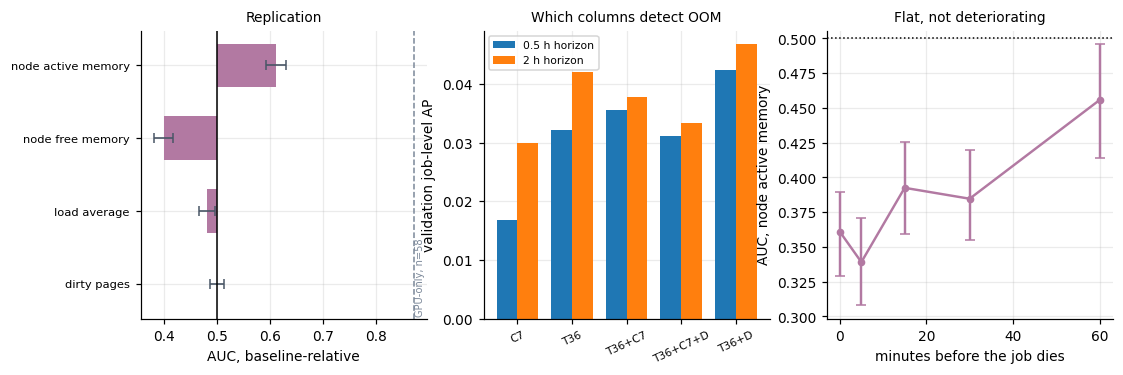

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4))

ax = axes[0]
d_ = A[A.kind == "baseline-relative"].sort_values("sep")
y_ = np.arange(len(d_))
ax.barh(y_, d_.auc - 0.5, left=0.5, color="#b279a2", height=.6)
ax.errorbar(d_.auc, y_, xerr=[d_.auc - d_.lo, d_.hi - d_.auc], fmt="none",
            ecolor="#495666", elinewidth=1.1, capsize=3)
ax.axvline(0.5, color="k", lw=1)
ax.axvline(0.871, color="#7b8899", ls="--", lw=1)
ax.text(0.874, -0.42, "GPU-only, n=58", fontsize=6.5, color="#7b8899", rotation=90)
ax.set_yticks(y_); ax.set_yticklabels(d_.metric, fontsize=7.5)
ax.set_xlabel("AUC, baseline-relative"); ax.set_title("Replication", fontsize=9)

ax = axes[1]
pv = V.pivot(index="horizon_h", columns="features", values="val_job_ap")
xs = np.arange(len(pv.columns))
for i, H in enumerate(pv.index):
    ax.bar(xs + (i - .5) * .38, pv.loc[H], .38, label=f"{H:g} h horizon")
ax.set_xticks(xs)
ax.set_xticklabels([c.split()[0] for c in pv.columns], fontsize=7, rotation=25)
ax.set_ylabel("validation job-level AP"); ax.legend(fontsize=7)
ax.set_title("Which columns detect OOM", fontsize=9)

ax = axes[2]
ax.errorbar(L.lead_min, L.auc, yerr=[L.auc - L.lo, L.hi - L.auc], marker="o", ms=4,
            color="#b279a2", lw=1.6, capsize=3)
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.set_xlabel("minutes before the job dies"); ax.set_ylabel("AUC, node active memory")
ax.set_title("Flat, not deteriorating", fontsize=9)
save(fig, "03_oom.png"); plt.show()

## Step 5 - What this settles

The verdicts above are the result. Three things they cannot settle, whichever way they
landed:

* **Prevalence is still prevalence.** 1,303 scorable OOM jobs out of 92,059 is 1.4 %.
  A detector for a 1.4 % event needs a very high precision to be worth deploying, which
  is why the operating-point table matters more than the AP.
* **This is one mechanism.** An OOM detector does not predict `NODE_FAIL` or `FAILED`,
  and those are 72 % of failures. It is a narrow tool, and the narrowness is the point.
* **The observability ceiling is untouched.** 4,499 OOM jobs exist; 1,303 run long
  enough to be scored. The other 3,196 are gone before any 20-minute window closes.

In [15]:
json.dump(facts, open(DATA / "facts_03.json", "w"), indent=1)
for k, v in facts.items():
    if k != "operating_points":
        print(f"{k:24s} {v}")

O1                       False
oom_auc                  0.6114922906676175
oom_auc_lo               0.5917801858848231
oom_auc_hi               0.6296176254046124
oom_jobs_raw             1863
O2                       True
O3                       True
val_ap_telemetry         0.04209617529355487
val_ap_context           0.02991048532103556
val_ap_delta             0.04676154210554124
selected_horizon_h       2.0
selected_features        T36+D  telemetry + deltas
test_job_ap              0.05596081942234062
test_job_ap_lo           0.047506870580166984
test_job_ap_hi           0.06689990411430023
test_base                0.01670889130172518
test_oom_jobs            277
test_jobs                16578
O4                       False
leadtime_spread          0.11660142829280362
